<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/AMAZON_fine_food_review_RNN%7CLSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **#Amazon Fine Food Reviews**
Analyze ~500,000 food reviews from Amazon

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

os is used to connect directly with the dataset by taking the cache

In [3]:
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
csv_file = os.path.join(path,'Reviews.csv')
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [4]:
df.head(2)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


In [5]:
df.shape

(568454, 10)

In [6]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


we only need user's text and score

In [7]:
df_clean = df[['Score','Text']]

In [8]:
df_clean

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...
...,...,...
568449,5,Great for sesame chicken..this is a good if no...
568450,2,I'm disappointed with the flavor. The chocolat...
568451,5,"These stars are small, so you can give 10-15 o..."
568452,5,These are the BEST treats for training and rew...


In [9]:
df_clean.isnull().sum()

,0
Score,0
Text,0


In [10]:
df_clean['Text'][2]

'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.'

In [11]:
df_clean['Score'][2]

np.int64(4)

In [12]:
#rating distribution
score_counts = df_clean['Score'].value_counts().sort_index()
print('\nPercentage')
for score, count in score_counts.items():
  perc = (count/len(df_clean)) * 100
  print(f"{score} 🌟 : {perc:.2f}%")


Percentage
1 🌟 : 9.19%
2 🌟 : 5.24%
3 🌟 : 7.50%
4 🌟 : 14.19%
5 🌟 : 63.88%


we can clearly see there is a data emblance

Q: which product is given more preference and which product gives leass preference

In [13]:
product_stat= df.groupby('ProductId')['Score'].agg(['mean', 'count'])

most_preferred= product_stat[product_stat['count']>50].sort_values(by='mean', ascending=False)
most_preferred.head(1)


,mean,count
ProductId,,
B000ED9L9E,4.973451,113


In [14]:
least_preferred= product_stat[product_stat['count']>50].sort_values(by='mean', ascending=True)
least_preferred.head(1)

,mean,count
ProductId,,
B006N3I69A,1.343511,131


In [15]:
for score in [1,2,3,4,5]:
  sample_review = df_clean[df_clean['Score'] == score]['Text'].iloc[0]
  print(f"\n🌟 {score}-STAR reviews")
  print(f"'{sample_review}'")


🌟 1-STAR reviews
'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'

🌟 2-STAR reviews
'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.'

🌟 3-STAR reviews
'This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.'

🌟 4-STAR reviews
'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly 

In [16]:
df_clean['text_length'] = df_clean['Text'].str.len()
df_clean['word_count'] = df_clean['Text'].str.split().str.len()

/tmp/ipython-input-1053056101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_length'] = df_clean['Text'].str.len()
/tmp/ipython-input-1053056101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['word_count'] = df_clean['Text'].str.split().str.len()


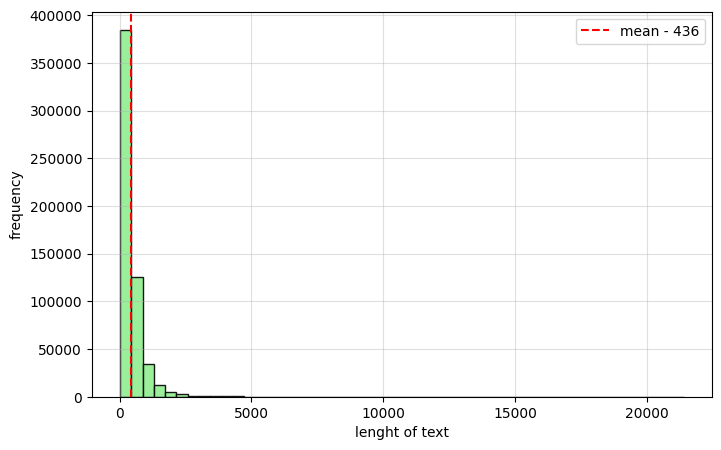

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['text_length'], bins= 50, color= 'lightgreen', alpha= 0.9, edgecolor= 'black')
plt.grid(alpha= 0.4)
plt.xlabel('lenght of text')
plt.ylabel('frequency')
plt.axvline(df_clean['text_length'].mean(), linestyle= '--', color = 'red', label = (f'mean - {df_clean['text_length'].mean() :.0f}'))
plt.legend()
plt.show()

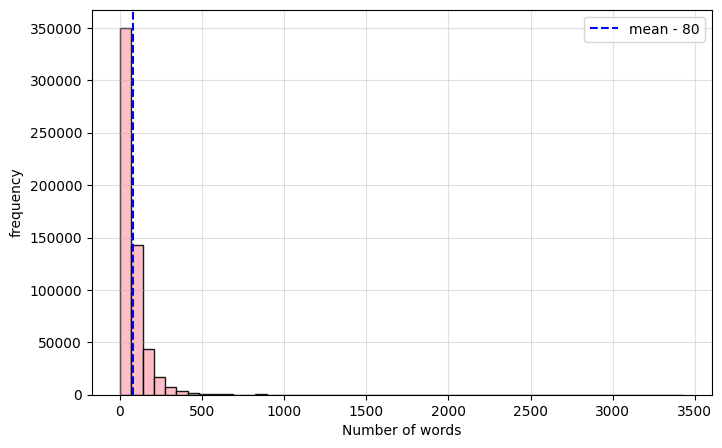

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['word_count'], bins= 50, color= 'lightpink', alpha= 0.9, edgecolor= 'black')
plt.grid(alpha= 0.4)
plt.xlabel('Number of words')
plt.ylabel('frequency')
plt.axvline(df_clean['word_count'].mean(), linestyle= '--', color = 'blue', label = (f'mean - {df_clean['word_count'].mean() :.0f}'))
plt.legend()
plt.show()

# divide the data for scoring
1,2 - neg - 0

4,5 - pos - 1

3 = removed all 3 my data , confused

In [19]:
df_binary = df_clean[df_clean['Score']!= 3].copy()
df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)
df_binary

,Score,Text,text_length,word_count,sentiment
0,5,I have bought several of the Vitality canned d...,263,48,1
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31,0
2,4,This is a confection that has been around a fe...,509,94,1
3,2,If you are looking for the secret ingredient i...,219,41,0
4,5,Great taffy at a great price. There was a wid...,140,27,1
...,...,...,...,...,...
568449,5,Great for sesame chicken..this is a good if no...,149,26,1
568450,2,I'm disappointed with the flavor. The chocolat...,252,46,0
568451,5,"These stars are small, so you can give 10-15 o...",372,66,1
568452,5,These are the BEST treats for training and rew...,200,35,1


In [27]:
print(f"Original Dataset : {len(df_clean):,} reviews")
print(f"After removing 3 start revi : {len(df_binary):,} reviews")
print(f"\nClass Distribution")
print(f"Negative (1-2 stars) : {sum(df_binary['sentiment']==0):,}")
print(f"Positive (4-5 stars) : {sum(df_binary['sentiment']==1):,}")
print(f"\nClass Distribution Percentage")
neg_pct = (sum(df_binary['sentiment']==0) / len(df_binary)) * 100
pos_pct = (sum(df_binary['sentiment']==1) / len(df_binary)) * 100
print(f"Negative (1-2 stars) in % : {neg_pct:.2f}%")
print(f"Negative (4-5 stars) in % : {pos_pct:.2f}%")

Original Dataset : 568,454 reviews
After removing 3 start revi : 525,814 reviews

Class Distribution
Negative (1-2 stars) : 82,037
Positive (4-5 stars) : 443,777

Class Distribution Percentage
Negative (1-2 stars) in % : 15.60%
Negative (4-5 stars) in % : 84.40%


In [28]:
#there is a clear class imbalance, heavy imbalance

In [29]:
from sklearn.utils import resample